In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv("../data/processed/preprocessed_reviews.csv")

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=10,
    max_df=0.5,
    ngram_range=(1, 2)
)

#X = vectorizer.fit_transform(df["clean_review"])

In [22]:
df_sample = df.sample(n=50000, random_state=42)
X = vectorizer.fit_transform(df_sample["clean_review"])

In [23]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

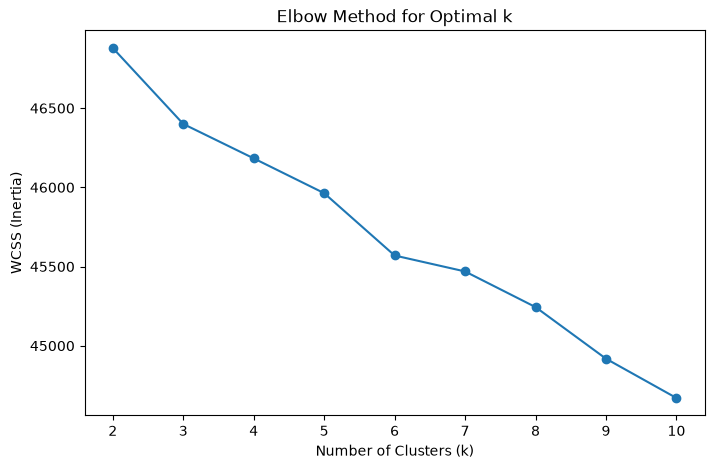

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), wcss, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")

plt.show()

In [25]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

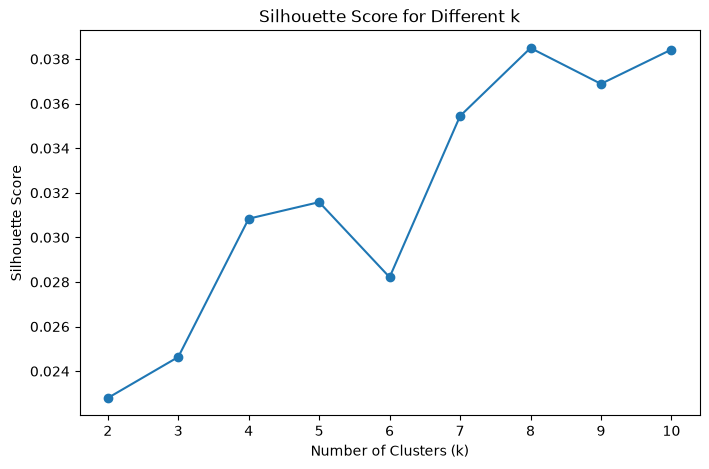

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")

plt.show()

In [26]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {score:.4f}")

k=2: 0.0224
k=3: 0.0294
k=4: 0.0252
k=5: 0.0218
k=6: 0.0306
k=7: 0.0277
k=8: 0.0310
k=9: 0.0317
k=10: 0.0368


In [27]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

df_sample["cluster"] = kmeans.fit_predict(X)

In [28]:
df_sample.head()

,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,steamid,num_games_owned,num_reviews,playtime_forever,playtime_last_two_weeks,playtime_at_review,last_played,review_length,clean_review,cluster
245914,82126815,english,"As it stands, this game is horribly bugged, qu...",1607734751,1607734779,False,0,0,0.0,0,...,76561198026567212,118,3,1450.0,0.0,743,1.695345e+09,335,stands game horribly bugged quite unoptimized ...,5
55419,127070037,english,Do not play without mods,1669484162,1669484162,True,0,0,0.0,0,...,76561198077242108,162,14,13500.0,0.0,13371,1.694108e+09,24,play without mods,5
249280,82114197,english,worth buying for... :D,1607724761,1607724761,True,0,0,0.0,0,...,76561198877841018,0,3,3586.0,0.0,1503,1.609122e+09,22,worth buying,5
122220,89793669,english,Still a lil buggy but man is it fun stacking i...,1617657529,1617657529,True,0,0,0.0,0,...,76561198043494764,0,12,6998.0,0.0,2768,1.697202e+09,102,still lil buggy man fun stacking intelligence ...,5
212496,82373356,english,Bug and crash\n\nEdit: mostly fixed game by now,1607979666,1669321670,False,1,0,0.0,0,...,76561198110230797,238,28,3751.0,0.0,388,1.662411e+09,45,bug crash edit mostly fixed game,5


In [29]:
df_sample["cluster"].value_counts().sort_index()

cluster
0      259
1    13614
2     1479
3     1051
4      592
5    31242
6      543
7     1220
Name: count, dtype: int64

In [30]:
import pandas as pd

terms = vectorizer.get_feature_names_out()

cluster_centers = kmeans.cluster_centers_

top_words = {}

for i, center in enumerate(cluster_centers):
    top_indices = center.argsort()[-10:][::-1]

    words = [terms[index] for index in top_indices]

    top_words[i] = words

pd.DataFrame(top_words)

,0,1,2,3,4,5,6,7
0,fuck,like,good,great,fun,good,yes,best
1,wake fuck,story,good game,great game,fun game,bugs,yes yes,best game
2,wake,bugs,game good,great story,pretty fun,amazing,buggy yes,ever
3,fuck samurai,really,good good,game great,game fun,fun,gud,game ever
4,fuck game,world,really good,story,pretty,love,buggy,played
5,samurai,good,good story,bugs,really fun,great,nice,one best
6,burn,time,really,still great,glitchy,story,yes good,ever played
7,shit,get,game bugs,buggy,fun play,nice,absolutely,one
8,city burn,even,finally,game bugs,fun fun,buggy,bugs yes,best games
9,samurai city,play,story,still,really,still,much,games
